In [12]:
# Install library NLP Bahasa Indonesia
!pip install Sastrawi       # Stemmer & Stopwords Bahasa Indonesia
!pip install nltk
!pip install pandas numpy matplotlib seaborn

import nltk
nltk.download('punkt')
nltk.download('stopwords')

print('Semua library berhasil diinstall!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 3.8 MB/s eta 0:00:00


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


✅ Semua library berhasil diinstall!


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Load dataset

In [13]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────────────────
# Jika pakai Google Colab: upload file atau mount Google Drive
# Option A: Upload manual
# from google.colab import files
# uploaded = files.upload()

# Option B: Mount Google Drive
# from google.colab import drive
# drive.mount('/content/drive')
# df = pd.read_csv('/content/drive/MyDrive/social_media_combined.csv')

# Option C: Load langsung jika sudah di-upload ke Colab
df = pd.read_csv('social_media_combined.csv', low_memory=False)
# ─────────────────────────────────────────────────────────

print(f'Shape awal: {df.shape}')
print(f'\n Kolom tersedia:')
print(df.columns.tolist())
df.head(3)

Shape awal: (9148, 23)

 Kolom tersedia:
['conversation_id_str', 'created_at', 'favorite_count', 'full_text', 'id_str', 'image_url', 'in_reply_to_screen_name', 'lang', 'location', 'quote_count', 'reply_count', 'retweet_count', 'tweet_url', 'user_id_str', 'username', 'year', 'source', 'comment_id', 'author', 'comment_text', 'published_at', 'like_count', 'video_id']


,conversation_id_str,created_at,favorite_count,full_text,id_str,image_url,in_reply_to_screen_name,lang,location,quote_count,...,user_id_str,username,year,source,comment_id,author,comment_text,published_at,like_count,video_id
0,1.570000e+18,2022-09-13 07:11:41+00:00,11.0,KPU - Komisi Pemilihan Umum Indonesia \n*G I L...,1.570000e+18,https://pbs.twimg.com/ext_tw_video_thumb/15695...,NaN,in,NaN,0.0,...,1.480000e+18,Aw_Rayy,2022.0,X,NaN,NaN,NaN,NaN,NaN,NaN
1,1.570000e+18,2022-09-18 01:09:35+00:00,9.0,Mahfud MD Klaim Tak Ada Data Penting yang Boco...,1.570000e+18,NaN,NaN,in,NaN,0.0,...,1.230000e+18,MediaKomando,2022.0,X,NaN,NaN,NaN,NaN,NaN,NaN
2,1.570000e+18,2022-09-15 03:09:20+00:00,4.0,"Bjorka Diduga Kuat Orang Asli Indonesia, Forum...",1.570000e+18,NaN,NaN,in,NaN,0.0,...,1.230000e+18,MediaKomando,2022.0,X,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
# Cek distribusi sumber data
print('📊 Distribusi Source:')
print(df['source'].value_counts())

# Cek missing values pada kolom teks utama
print('\n🔍 Missing Values:')
print(f"  Twitter (full_text)   : {df['full_text'].isna().sum()} missing")
print(f"  YouTube (comment_text): {df['comment_text'].isna().sum()} missing")

📊 Distribusi Source:
source
Youtube    5341
X          3807
Name: count, dtype: int64

🔍 Missing Values:
  Twitter (full_text)   : 5341 missing
  YouTube (comment_text): 3815 missing


In [15]:
df_twitter = df[df['source'] == 'X'][['full_text', 'source', 'year']].rename(columns={'full_text': 'text'})
df_youtube = df[df['source'] == 'Youtube'][['comment_text', 'source', 'year']].rename(columns={'comment_text': 'text'})

In [16]:
# Gabungkan
df_combined = pd.concat([df_twitter, df_youtube], ignore_index=True)

In [18]:
# Hapus baris dengan teks kosong
df_combined = df_combined.dropna(subset=['text'])
df_combined['text'] = df_combined['text'].astype(str).str.strip()
df_combined = df_combined[df_combined['text'] != '']  # buang teks kosong
df_combined = df_combined[df_combined['text'] != 'nan']
df_combined = df_combined.reset_index(drop=True)

print(f'✅ Total data gabungan: {len(df_combined)} baris')
print(f'   - Twitter/X : {len(df_combined[df_combined["source"]=="X"])} baris')
print(f'   - YouTube   : {len(df_combined[df_combined["source"]=="Youtube"])} baris')
df_combined.head()

✅ Total data gabungan: 9140 baris
   - Twitter/X : 3807 baris
   - YouTube   : 5333 baris


,text,source,year
0,KPU - Komisi Pemilihan Umum Indonesia \n*G I L...,X,2022.0
1,Mahfud MD Klaim Tak Ada Data Penting yang Boco...,X,2022.0
2,"Bjorka Diduga Kuat Orang Asli Indonesia, Forum...",X,2022.0
3,"Tegaskan Tak Ada Data Negara Bocor, Mahfud MD:...",X,2022.0
4,"Terbaru, Bjorka Bocorkan Data Menko Polhukam M...",X,2022.0


Fungsi Preprocessing

In [19]:
import html

In [20]:
# ── 3.1 Lowercase Conversion ──────────────────────────────
def lowercase(text):
    """Konversi seluruh teks ke huruf kecil"""
    return text.lower()

In [21]:
# ── 3.2 HTML Entity Decoding ──────────────────────────────
def decode_html_entities(text):
    """Decode HTML entities seperti &amp; → &, &lt; → <, &gt; → >"""
    return html.unescape(text)

In [22]:
# ── 3.3 URL Elimination ───────────────────────────────────
def remove_url(text):
    """Hapus semua URL (http, https, www, t.co, dll)"""
    text = re.sub(r'http\S+|https\S+|www\.\S+', '', text)
    text = re.sub(r't\.co/\S+', '', text)  # khusus Twitter short URL
    return text

In [23]:
# ── 3.4 @username Removing ────────────────────────────────
def remove_username(text):
    """Hapus mention @username"""
    return re.sub(r'@\w+', '', text)

In [25]:
# ── 3.5 Hashtag Removing ──────────────────────────────────
def remove_hashtag(text):
    """Hapus hashtag #topik (tanda # dan kata setelahnya)"""
    return re.sub(r'#\w+', '', text)

In [26]:
# ── 3.6 Emoji & Simbol Removing ───────────────────────────
def remove_emoji(text):
    """Hapus emoji dan karakter Unicode non-standar"""
    emoji_pattern = re.compile(
        "["
        u"\U0001F600-\U0001F64F"  # emoticons
        u"\U0001F300-\U0001F5FF"  # symbols & pictographs
        u"\U0001F680-\U0001F6FF"  # transport & map
        u"\U0001F1E0-\U0001F1FF"  # flags
        u"\U00002702-\U000027B0"
        u"\U000024C2-\U0001F251"
        "]+",
        flags=re.UNICODE
    )
    return emoji_pattern.sub('', text)

In [27]:
# ── 3.7 Hapus Karakter Khusus & Tanda Baca ────────────────
def remove_special_chars(text):
    """Hapus karakter non-alfanumerik, sisakan spasi"""
    # Simpan tanda hubung dalam kata (misal: hacker-hackeran)
    text = re.sub(r'[^\w\s]', ' ', text)  # hapus tanda baca
    text = re.sub(r'\d+', '', text)         # hapus angka
    return text

In [28]:
# ── 3.8 Normalisasi Whitespace ────────────────────────────
def normalize_whitespace(text):
    """Hilangkan spasi berlebih dan newline"""
    text = re.sub(r'[\r\n\t]+', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

print('✅ Fungsi preprocessing dasar telah didefinisikan.')

✅ Fungsi preprocessing dasar telah didefinisikan.


In [29]:
# ── 3.9 Normalisasi Slang / Kata Tidak Baku (Bahasa Indonesia) ──
# Kamus slang umum media sosial Indonesia
slang_dict = {
    'yg': 'yang', 'dgn': 'dengan', 'tdk': 'tidak', 'ga': 'tidak',
    'gak': 'tidak', 'gk': 'tidak', 'nggak': 'tidak', 'ndak': 'tidak',
    'aja': 'saja', 'aj': 'saja', 'nih': 'ini', 'tuh': 'itu',
    'utk': 'untuk', 'krn': 'karena', 'karna': 'karena', 'krena': 'karena',
    'pd': 'pada', 'dr': 'dari', 'ke': 'ke', 'tp': 'tapi',
    'tapi': 'tetapi', 'hrs': 'harus', 'sdh': 'sudah', 'udh': 'sudah',
    'udah': 'sudah', 'blm': 'belum', 'belom': 'belum',
    'bgt': 'banget', 'banget': 'sangat', 'byk': 'banyak',
    'sy': 'saya', 'sya': 'saya', 'aku': 'saya', 'gw': 'saya',
    'gue': 'saya', 'lo': 'kamu', 'lu': 'kamu', 'loe': 'kamu',
    'mereka': 'mereka', 'kita': 'kita', 'kt': 'kita',
    'jd': 'jadi', 'jadi': 'jadi', 'dg': 'dengan',
    'lg': 'lagi', 'lagi': 'lagi', 'msh': 'masih',
    'org': 'orang', 'orng': 'orang', 'kmrn': 'kemarin',
    'bs': 'bisa', 'bsa': 'bisa', 'emg': 'memang', 'emang': 'memang',
    'sbg': 'sebagai', 'sbgai': 'sebagai', 'ttg': 'tentang',
    'isu': 'isu', 'bocor': 'bocor', 'hack': 'retas', 'hacker': 'peretas',
    'hacked': 'diretas', 'fix': 'pasti', 'coy': '', 'bro': '',
    'guys': '', 'wkwkwk': '', 'haha': '', 'hehe': '', 'hihi': ''
}

def normalize_slang(text):
    """Ganti kata slang dengan kata baku berdasarkan kamus"""
    words = text.split()
    normalized = [slang_dict.get(w, w) for w in words]
    return ' '.join([w for w in normalized if w != ''])  # buang kata kosong

print('✅ Kamus slang siap (', len(slang_dict), 'entri )')

✅ Kamus slang siap ( 70 entri )


In [30]:
# ── 3.10 Stopwords Bahasa Indonesia (Sastrawi + Custom) ──
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# Inisialisasi stopword remover
sw_factory = StopWordRemoverFactory()
sastrawi_stopwords = set(sw_factory.get_stop_words())

# Tambahkan stopwords custom sesuai konteks dataset
custom_stopwords = {
    'ya', 'yah', 'wah', 'oh', 'ah', 'eh', 'ih', 'uh',
    'nya', 'lah', 'deh', 'dong', 'kok', 'sih', 'kan',
    'nih', 'tuh', 'itu', 'ini', 'yuk', 'hei',
    'mah', 'nah', 'hm', 'hmm', 'em', 'emm',
    'pak', 'bu', 'mas', 'mbak', 'bang', 'bro', 'sis',
    'rt', 'rw', 'no', 'nomor'
}

all_stopwords = sastrawi_stopwords.union(custom_stopwords)

def remove_stopwords(text):
    """Hapus stopwords dari teks"""
    words = text.split()
    return ' '.join([w for w in words if w not in all_stopwords and len(w) > 1])

print(f'✅ Total stopwords: {len(all_stopwords)} kata')

✅ Total stopwords: 157 kata


In [31]:
# ── 3.11 Stemming Bahasa Indonesia (Sastrawi) ────────────
stem_factory = StemmerFactory()
stemmer = stem_factory.create_stemmer()

def stem_text(text):
    """Stemming kata ke bentuk dasar (Bahasa Indonesia)"""
    return stemmer.stem(text)

# Test singkat
contoh = 'kebocoran data pribadi masyarakat Indonesia sangat mengkhawatirkan'
print('Contoh stemming:')
print(f'  Sebelum : {contoh}')
print(f'  Sesudah : {stemmer.stem(contoh)}')

Contoh stemming:
  Sebelum : kebocoran data pribadi masyarakat Indonesia sangat mengkhawatirkan
  Sesudah : bocor data pribadi masyarakat indonesia sangat khawatir


Pipeline Preprocessing

In [32]:
def preprocess_pipeline(text, use_stemming=True):
    """
    Full preprocessing pipeline:
    1. Lowercase
    2. Decode HTML entities
    3. Hapus URL
    4. Hapus @username
    5. Hapus #hashtag
    6. Hapus emoji
    7. Normalisasi slang
    8. Hapus karakter khusus & angka
    9. Normalisasi whitespace
    10. Hapus stopwords
    11. Stemming (opsional)
    """
    text = str(text)
    text = lowercase(text)               # Step 1
    text = decode_html_entities(text)    # Step 2
    text = remove_url(text)              # Step 3
    text = remove_username(text)         # Step 4
    text = remove_hashtag(text)          # Step 5
    text = remove_emoji(text)            # Step 6
    text = normalize_slang(text)         # Step 7
    text = remove_special_chars(text)    # Step 8
    text = normalize_whitespace(text)    # Step 9
    text = remove_stopwords(text)        # Step 10
    if use_stemming:
        text = stem_text(text)           # Step 11
    return text

print('✅ Pipeline preprocessing siap.')

✅ Pipeline preprocessing siap.


In [33]:
# Tes pipeline pada 3 contoh teks
contoh_teks = [
    df_combined['text'].iloc[0],
    df_combined['text'].iloc[100],
    df_combined['text'].iloc[500]
]

print('=== CONTOH HASIL PREPROCESSING ===\n')
for i, t in enumerate(contoh_teks):
    print(f'[Contoh {i+1}]')
    print(f'  SEBELUM: {t[:200]}...')
    print(f'  SESUDAH: {preprocess_pipeline(t)[:200]}...')
    print()

=== CONTOH HASIL PREPROCESSING ===

[Contoh 1]
  SEBELUM: KPU - Komisi Pemilihan Umum Indonesia 
*G I L A &amp; B A J I N G A N S E M U A N Y A*

Ternyata data pemilu 2024 sudah jadi, yang akhirnya data tersebut bocor juga ke publik.
Endingnya, nanti sudah d...
  SESUDAH: kpu komisi pilih umum indonesia nyata data milu jadi akhir data sebut bocor publik endingnya tetap siapa menang milu guna partai kuasa...

[Contoh 2]
  SEBELUM: Kata Pak Mahfud MD tentang data yang bocor, "informasi yang dibocorkan hacker Bjorka sejauh ini adalah data yang sudah terpublikasi di media."

Malah ketawa-ketawa😬 https://t.co/VEBQEsO4aK...
  SESUDAH: kata mahfud md data bocor informasi bocor retas bjorka jauh data publikasi media malah ketawa ketawa...

[Contoh 3]
  SEBELUM: UU PDP itu TIDAK menjamin keamanan data pribadi kita.

UU PDP itu adalah (1) memungkinkan pemerintah lempar kesalahan pada vendor, dan (2) menghukum, bukan mencegah.

cc @secgron @ismailfahmi @slaksmi...
  SESUDAH: uu pdp jamin aman dat

In [34]:
from tqdm.notebook import tqdm  # progress bar
tqdm.pandas()

print('🔄 Menjalankan preprocessing pada seluruh dataset...')

# Terapkan pipeline (gunakan use_stemming=False jika ingin lebih cepat / pakai model modern)
df_combined['text_clean'] = df_combined['text'].progress_apply(
    lambda x: preprocess_pipeline(x, use_stemming=True)
)

print('\n✅ Preprocessing selesai!')
print(f'   Total baris: {len(df_combined)}')

🔄 Menjalankan preprocessing pada seluruh dataset...


  0%|          | 0/9140 [00:00<?, ?it/s]


✅ Preprocessing selesai!
   Total baris: 9140


Filter dan Validasi Hasil

In [35]:
# Hapus teks yang jadi kosong setelah preprocessing
before = len(df_combined)
df_combined = df_combined[df_combined['text_clean'].str.strip() != '']
df_combined = df_combined[df_combined['text_clean'].str.len() > 5]  # min 5 karakter
df_combined = df_combined.reset_index(drop=True)
after = len(df_combined)

print(f'📋 Data sebelum filter: {before}')
print(f'📋 Data setelah filter : {after}')
print(f'🗑️  Data dihapus        : {before - after}')

# Tambah kolom panjang token untuk analisis
df_combined['token_count'] = df_combined['text_clean'].apply(lambda x: len(x.split()))

print('\n📊 Statistik panjang teks bersih:')
print(df_combined['token_count'].describe())

📋 Data sebelum filter: 9140
📋 Data setelah filter : 9136
🗑️  Data dihapus        : 4

📊 Statistik panjang teks bersih:
count    9136.000000
mean       18.634194
std        14.505909
min         2.000000
25%         9.000000
50%        16.000000
75%        24.000000
max       312.000000
Name: token_count, dtype: float64


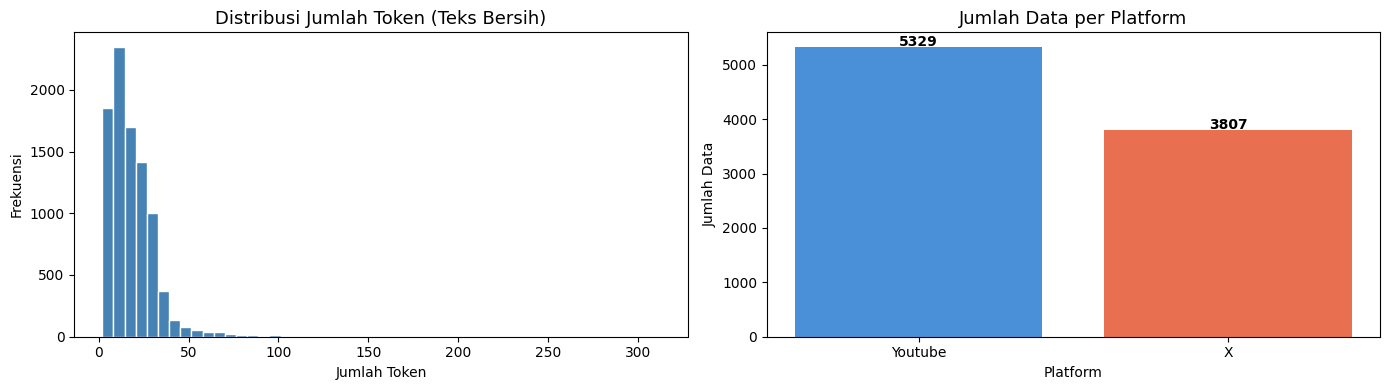

In [36]:
# Visualisasi distribusi panjang teks
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram jumlah token
axes[0].hist(df_combined['token_count'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribusi Jumlah Token (Teks Bersih)', fontsize=13)
axes[0].set_xlabel('Jumlah Token')
axes[0].set_ylabel('Frekuensi')

# Bar chart per source
source_counts = df_combined['source'].value_counts()
axes[1].bar(source_counts.index, source_counts.values, color=['#4A90D9', '#E87050'])
axes[1].set_title('Jumlah Data per Platform', fontsize=13)
axes[1].set_xlabel('Platform')
axes[1].set_ylabel('Jumlah Data')
for i, v in enumerate(source_counts.values):
    axes[1].text(i, v + 10, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [37]:
# Tampilkan sampel hasil akhir
print('=== SAMPEL 5 DATA HASIL PREPROCESSING ===')
pd.set_option('display.max_colwidth', 120)
df_combined[['source', 'text', 'text_clean']].sample(5)

=== SAMPEL 5 DATA HASIL PREPROCESSING ===


,source,text,text_clean
6419,Youtube,Jika Data itu Bobol.. Berarti.. Ada Tim Nya Di Lingkaran Ring 1,data bobol arti tim lingkar ring
5741,Youtube,"Hiii.. JANGAN MEREMEHKAN DATA ANDA / DATA PROFILE ANDA...\n\nDATA anda sangat mahal utk dipublikasikan, Jika suatu s...",hiii jangan remeh data data profile data sangat mahal publikasi suatu mau registrasi data pakai salah satu credit ca...
8467,Youtube,Itu semua bohong. /. Tampa di berikan pun data pribadi sudah pada keluar karena /. Alat alat maju yang sudah tidak ...,semua bohong tampa ikan data pribadi keluar alat alat maju bendung bangyak contoh bila mau sebut
5469,Youtube,Harusnya tu hacker di kasih kerjaan di kementerian untuk bantu jaga data. Dia tau cara bobol data otomatis dia juga ...,harus tu retas kasih kerja menteri bantu jaga data tau cara bobol data otomatis tau gimana cara nutup data bukan kas...
4449,Youtube,"Kalo sekelas outsourcing dapat ngakses data, tutup aja telkomsel, nggak percaya",kalo kelas outsourcing ngakses data tutup telkomsel percaya


Simpan Dataset Bersih

In [38]:
# Simpan dataset lengkap (dengan teks asli + teks bersih)
df_save = df_combined[['source', 'year', 'text', 'text_clean', 'token_count']]
df_save.to_csv('social_media_preprocessed.csv', index=False)

# Simpan versi minimal (hanya text_clean untuk training)
df_save[['text_clean', 'source']].to_csv('social_media_clean_only.csv', index=False)

print('✅ Dataset berhasil disimpan!')
print('   📄 social_media_preprocessed.csv  → dataset lengkap')
print('   📄 social_media_clean_only.csv    → siap untuk training')

# Download file dari Colab
# from google.colab import files
# files.download('social_media_preprocessed.csv')

✅ Dataset berhasil disimpan!
   📄 social_media_preprocessed.csv  → dataset lengkap
   📄 social_media_clean_only.csv    → siap untuk training


Cleaning dan filtering konteks

In [43]:
# ── Jalankan ini setelah pipeline preprocessing selesai ──

# F1 — Hapus duplikat pada text_clean
before = len(df_combined)
df_combined = df_combined.drop_duplicates(subset='text_clean').reset_index(drop=True)
print(f"Duplikat dihapus: {before - len(df_combined)}")

# F2 — Length filter (hapus teks terlalu pendek)
df_combined['token_count'] = df_combined['text_clean'].str.split().str.len()
df_filtered = df_combined[df_combined['token_count'] >= 3].reset_index(drop=True)

print(f"Setelah length filter: {len(df_filtered)}")

# Hapus kolom token_count (opsional agar bersih)
df_filtered = df_filtered.drop(columns='token_count')

print(f"\n✅ Dataset final: {len(df_filtered)} baris")

# Simpan
df_filtered.to_csv('social_media_preprocessed_filtered.csv', index=False)

Duplikat dihapus: 0
Setelah length filter: 8636

✅ Dataset final: 8636 baris


In [42]:
# ── Jalankan ini setelah pipeline preprocessing selesai ──

# F1 — Hapus duplikat pada text_clean
before = len(df_combined)
df_combined = df_combined.drop_duplicates(subset='text_clean').reset_index(drop=True)
print(f"Duplikat dihapus: {before - len(df_combined)}")

# F2 — Length filter
df_combined['token_count'] = df_combined['text_clean'].str.split().str.len()
df_combined = df_combined[df_combined['token_count'] >= 3].reset_index(drop=True)
print(f"Setelah length filter: {len(df_combined)}")

# # F3 — Keyword filter (pada text_clean yang sudah lowercase)
# keywords_flat = [
#     'data', 'uu pdp', 'pdp', 'bocor', 'pemerintah', 'kebocoran', 'leak', 'breach', 'diretas', 'retas',
#     'data pribadi', 'data penduduk', 'data warga', 'data wni', 'menurut',
#     'nik', 'ktp', 'privasi', 'hacker', 'peretas', 'siber', 'cyber',
#     'uu pdp', 'perlindungan data', 'kominfo', 'bssn',
#     'bjorka', 'bpjs', 'kpu', 'pdn', 'dukcapil', 'indihome', 'telkomsel', 'percaya',
#     'transfer data', 'serahkan data', 'jual data', 'keamanan data'
# ]

# def is_relevant(text):
#     text = str(text).lower()
#     return any(kw in text for kw in keywords_flat)

# df_combined['relevant'] = df_combined['text_clean'].apply(is_relevant)
# print(f"Relevan: {df_combined['relevant'].sum()} / Tidak relevan: {(~df_combined['relevant']).sum()}")

df_filtered = df_combined[df_combined['relevant']].drop(columns='relevant').reset_index(drop=True)
print(f"\n✅ Dataset final: {len(df_filtered)} baris")

# Simpan
df_filtered.to_csv('social_media_preprocessed_filtered.csv', index=False)

Duplikat dihapus: 0
Setelah length filter: 8636


NameError: name 'df_filtered' is not defined